# Customer Churn Prediction — Random Forest

**Goal:** Predict which customers are likely to churn using RFM features  
**Model:** Random Forest Classifier (100 trees)  
**Features:** Recency, Frequency, Monetary  
**Target:** 1 = Churned (At Risk + Lost), 0 = Active  

## Results
- **Accuracy:** 96%
- **ROC-AUC:** 0.9955
- **Churned Recall:** 97% — catches nearly all churners
- **Key insight:** Recency is the strongest churn predictor (38% importance)
- **High risk profile:** Customers with Frequency = 1 and high Recency are almost certain churners

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load RFM data
rfm = pd.read_csv("../output/rfm_segments.csv")

# Create churn label — 1 = churned, 0 = active
rfm["Churn"] = rfm["Segment"].apply(lambda x: 1 if x in ["At Risk", "Lost"] else 0)

print(f"Churned: {rfm['Churn'].sum()} ({rfm['Churn'].mean()*100:.1f}%)")
print(f"Active:  {(rfm['Churn']==0).sum()} ({(rfm['Churn']==0).mean()*100:.1f}%)")
# Features — raw values only, no derived scores
X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Churn"]

Churned: 1291 (29.8%)
Active:  3047 (70.2%)


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(f"Training complete!")
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Training complete!
Train size: 3470 | Test size: 868


In [3]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Classification Report:
              precision    recall  f1-score   support

      Active       0.98      0.96      0.97       610
     Churned       0.92      0.97      0.94       258

    accuracy                           0.96       868
   macro avg       0.95      0.96      0.96       868
weighted avg       0.97      0.96      0.96       868

ROC-AUC Score: 0.9955


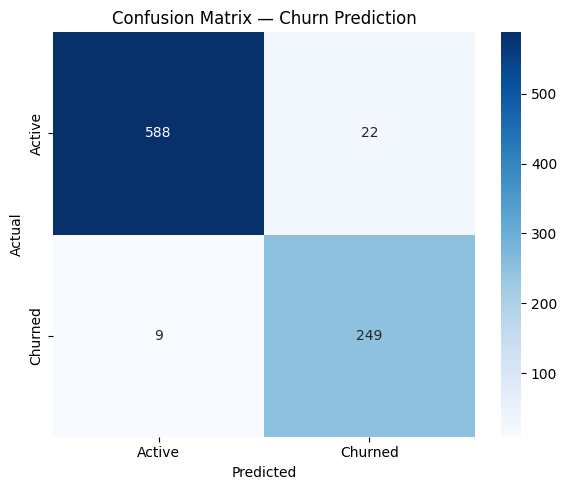

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active", "Churned"],
            yticklabels=["Active", "Churned"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Churn Prediction")
plt.tight_layout()
plt.savefig("../output/confusion_matrix.png", dpi=150)
plt.show()

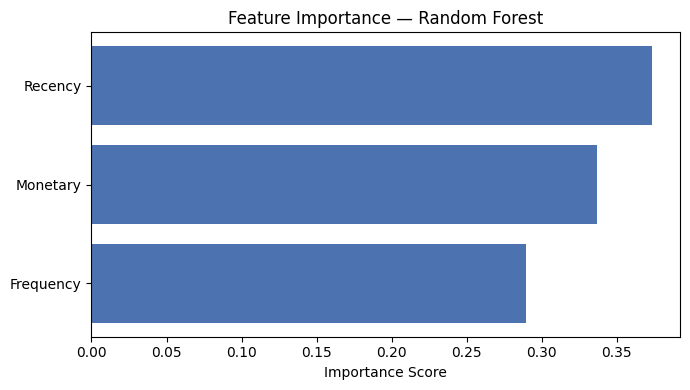

In [5]:
feat_importance = pd.DataFrame({
    "Feature": ["Recency", "Frequency", "Monetary"],
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(feat_importance["Feature"], feat_importance["Importance"], color="#4C72B0")
ax.set_xlabel("Importance Score")
ax.set_title("Feature Importance — Random Forest")
plt.tight_layout()
plt.savefig("../output/feature_importance.png", dpi=150)
plt.show()

In [6]:
rfm["Churn_Probability"] = model.predict_proba(X)[:, 1]

# Top 10 customers most likely to churn
high_risk = (rfm[rfm["Churn_Probability"] > 0.7]
             .sort_values("Churn_Probability", ascending=False)
             .head(10)
             [["CustomerID", "Recency", "Frequency", "Monetary", "Segment", "Churn_Probability"]]
             .reset_index(drop=True))

high_risk["Churn_Probability"] = high_risk["Churn_Probability"].apply(lambda x: f"{x:.1%}")
high_risk["Monetary"] = high_risk["Monetary"].apply(lambda x: f"£{x:,.2f}")
print(high_risk.to_string())

   CustomerID  Recency  Frequency Monetary  Segment Churn_Probability
0     15895.0      149          1  £179.17     Lost            100.0%
1     14647.0      200          1  £243.22     Lost            100.0%
2     16829.0      156          1  £197.22  At Risk            100.0%
3     16823.0      226          1  £358.38  At Risk            100.0%
4     14622.0      184          1  £320.58  At Risk            100.0%
5     15958.0       73          1  £104.35  At Risk            100.0%
6     14632.0      262          1  £114.56     Lost            100.0%
7     14633.0      265          1  £344.90  At Risk            100.0%
8     15970.0      303          1  £314.10  At Risk            100.0%
9     16796.0       88          1  £305.62  At Risk            100.0%
